<a href="https://colab.research.google.com/github/Priyasarkar11/AI_MOCK_INTERVIEWER/blob/main/8THsem_AI_MOCK_INTERVIEWER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import torch
print(torch.cuda.is_available())

True


In [20]:
from google.colab import files
uploaded = files.upload()

Saving train_final.csv to train_final (2).csv


In [21]:
import os
os.listdir()

['.config',
 'qgen_model',
 'train_final.csv',
 'train_final (2).csv',
 'train_final (1).csv',
 'qgen_model.zip',
 'sample_data']

In [22]:
!pip install transformers datasets sentencepiece accelerate -q

In [23]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

model_name = "google/flan-t5-small" # Changed to a smaller model variant

tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [24]:
import pandas as pd

data = pd.read_csv("train_final.csv")
data.head()

,input,output
0,generate medium database & sql interview question,Give an example where joins vs denormalization...
1,"Instruction: Given the candidate resume, job d...",What is the role of activation functions in de...
2,"Instruction: Given the candidate resume, job d...",Compare different approaches to rest api desig...
3,"Instruction: Given the candidate resume, job d...",Design an architecture or algorithm to solve s...
4,"Instruction: Given the candidate resume, job d...",Describe the trade-offs involved in technical ...


In [25]:
import pandas as pd

data = pd.read_csv("train_final.csv")
data.head()

,input,output
0,generate medium database & sql interview question,Give an example where joins vs denormalization...
1,"Instruction: Given the candidate resume, job d...",What is the role of activation functions in de...
2,"Instruction: Given the candidate resume, job d...",Compare different approaches to rest api desig...
3,"Instruction: Given the candidate resume, job d...",Design an architecture or algorithm to solve s...
4,"Instruction: Given the candidate resume, job d...",Describe the trade-offs involved in technical ...


In [26]:
encodings = tokenizer(
    data['input'].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

labels = tokenizer(
    data['output'].tolist(),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
).input_ids

In [27]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
encodings = {k: v.to(device) for k, v in encodings.items()}
labels = labels.to(device)

print(device)

cuda


In [29]:
from torch.utils.data import Dataset, DataLoader
import torch

class QGenDataset(Dataset):
    def __init__(self, inputs, targets, tokenizer, device):
        self.inputs = inputs
        self.targets = targets
        self.tokenizer = tokenizer
        self.device = device

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_enc = self.tokenizer(
            self.inputs[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        target_enc = self.tokenizer(
            self.targets[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": input_enc.input_ids.squeeze().to(self.device),
            "attention_mask": input_enc.attention_mask.squeeze().to(self.device),
            "labels": target_enc.input_ids.squeeze().to(self.device),
        }

dataset = QGenDataset(data['input'].tolist(), data['output'].tolist(), tokenizer, device)

loader = DataLoader(dataset, batch_size=2, shuffle=True) # Reduced batch size to 2

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

model.train()

for epoch in range(5):   # ⭐ increase epochs
    total_loss = 0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss:", total_loss)

Epoch 1 Loss: 10139.28892982006
Epoch 2 Loss: 2473.340016722679
Epoch 3 Loss: 853.262357391417
Epoch 4 Loss: 463.26159842312336
Epoch 5 Loss: 316.86474527046084


In [30]:
model.save_pretrained("qgen_model")
tokenizer.save_pretrained("qgen_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('qgen_model/tokenizer_config.json', 'qgen_model/tokenizer.json')

In [31]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("qgen_model")
model = T5ForConditionalGeneration.from_pretrained("qgen_model")
model = model.to(device) # Move the loaded model to the GPU

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [32]:
model.eval()

T5ForConditionalGeneration(
  (shared): Embedding(32128, 512)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 512)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
              (wo): 

In [35]:
!zip -r qgen_model.zip qgen_model

from google.colab import files
files.download("qgen_model.zip")

updating: qgen_model/ (stored 0%)
updating: qgen_model/config.json (deflated 63%)
updating: qgen_model/tokenizer.json (deflated 79%)
updating: qgen_model/generation_config.json (deflated 29%)
updating: qgen_model/tokenizer_config.json (deflated 83%)
updating: qgen_model/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
prompts = [
    "generate easy dbms interview question",
    "generate medium os interview question",
    "generate hard machine learning interview question"
]

for p in prompts:
    input_ids = tokenizer(p, return_tensors="pt").input_ids.to(device) # Move input_ids to the GPU
    output = model.generate(input_ids, max_length=64)
    print("Prompt:", p)
    print("Question:", tokenizer.decode(output[0], skip_special_tokens=True))
    print("-----")

Prompt: generate easy dbms interview question
Question: Explain the concept of cnn architectures with a short example.
-----
Prompt: generate medium os interview question
Question: Explain the concept of scalability with a short example.
-----
Prompt: generate hard machine learning interview question
Question: Design a solution: How would you approach model evaluation for a large-scale system?
-----


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define keywords for different technical topics
topic_keywords = {
    'Database/SQL': ['database', 'sql', 'dbms', 'join', 'normalization', 'denormalization', 'index', 'transaction', 'acid', 'nosql', 'relational', 'query', 'schema'],
    'Operating Systems': ['os', 'operating system', 'process', 'thread', 'memory management', 'deadlock', 'concurrency', 'scheduling', 'kernel', 'syscall'],
    'Machine Learning': ['machine learning', 'ml', 'neural network', 'cnn', 'rnn', 'lstm', 'transformer', 'algorithm', 'model', 'training', 'bias', 'variance', 'overfitting', 'underfitting', 'activation function', 'deep learning', 'supervised', 'unsupervised', 'reinforcement'],
    'Data Structures & Algorithms': ['data structure', 'algorithm', 'array', 'list', 'tree', 'graph', 'hash', 'sort', 'search', 'complexity', 'linked list', 'stack', 'queue'],
    'System Design/Architecture': ['system design', 'architecture', 'scalability', 'latency', 'consistency', 'availability', 'api', 'microservices', 'distributed system', 'load balancer', 'cache', 'fault tolerance', 'queueing', 'design patterns'],
    'Programming/Software Dev': ['python', 'java', 'c++', 'oop', 'testing', 'debugging', 'version control', 'git', 'refactoring', 'agile', 'technical debt', 'software development', 'framework'],
    'Web Development': ['web', 'frontend', 'backend', 'javascript', 'react', 'angular', 'vue', 'html', 'css', 'http', 'rest', 'graphql', 'browser'],
    'Cloud Computing': ['cloud', 'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'container', 'serverless']
}

def categorize_question(question):
    question_lower = str(question).lower()
    found_topics = []
    for topic, keywords in topic_keywords.items():
        if any(keyword in question_lower for keyword in keywords):
            found_topics.append(topic)

    if len(found_topics) == 1:
        return found_topics[0]
    elif len(found_topics) > 1:
        return 'Multiple Topics'
    else:
        return 'Other'

# Apply the categorization function to the 'output' column
data['topic'] = data['output'].apply(categorize_question)

# Get the distribution of topics
topic_distribution = data['topic'].value_counts().reset_index()
topic_distribution.columns = ['Topic', 'Count']

# Display the topic distribution
display(topic_distribution)


,Topic,Count
0,Other,2735
1,Multiple Topics,953
2,Machine Learning,620
3,System Design/Architecture,413
4,Operating Systems,356
5,Database/SQL,319
6,Data Structures & Algorithms,198
7,Programming/Software Dev,186
8,Web Development,173
9,Cloud Computing,29


/tmp/ipython-input-8511/2760073877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')


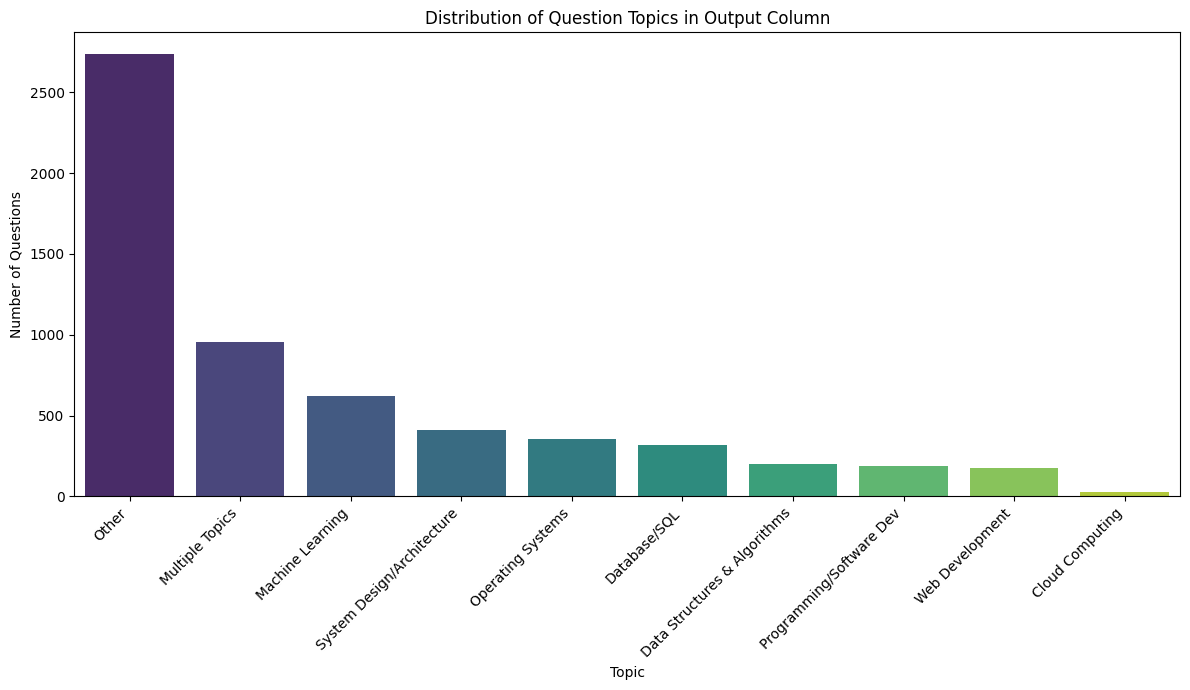

In [41]:
# Visualize the distribution of topics
plt.figure(figsize=(12, 7))
sns.barplot(x='Topic', y='Count', data=topic_distribution, palette='viridis')
plt.title('Distribution of Question Topics in Output Column')
plt.xlabel('Topic')
plt.ylabel('Number of Questions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()